In [1]:
import pdf2image  # PyMuPDF
import pytesseract
import cv2
import numpy as np
from PIL import Image
from pathlib import Path
import re
import json
import matplotlib.pyplot as plt

In [ ]:
pytesseract.pytesseract.tesseract_cmd = r"C:/Program Files/Tesseract-OCR/tesseract.exe"

pdf_path = Path("normal_test_more_text.pdf")

doc = pdf2image.convert_from_path(pdf_path) #creates list object 

#width 1700, length 2200

pil_image = doc[0]
cv2_image = np.array(pil_image)


In [26]:
height, width, _ = cv2_image.shape

print (height, width)

3300 2550


In [27]:
#FACILITY TYPE

type_start_point = (880, 330)
type_end_point = (1300, 480)

x1 = min(type_start_point[0], type_end_point[0])
x2 = max(type_start_point[0], type_end_point[0])
y1 = min(type_start_point[1], type_end_point[1])
y2 = max(type_start_point[1], type_end_point[1])

text = None
cv2_image = cv2.cvtColor(np.array(cv2_image), cv2.COLOR_RGB2BGR)
roi = cv2_image[y1:y2, x1:x2] #initial box for type of facility
blurred_image = cv2.GaussianBlur(roi, (5, 5), 0)
edges = cv2.Canny(blurred_image, 50, 150) #get contoured polygons
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
for contour in contours:
    approx = cv2.approxPolyDP(contour, 0.04 * cv2.arcLength(contour, True), True) #get polgyon curve
    if len(approx) == 4 and cv2.isContourConvex(approx):
        x, y, w, h = cv2.boundingRect(approx)
        aspect_ratio = float(w) / h
        area = cv2.contourArea(approx) 
        if 0.85 <= aspect_ratio <= 1.15 and 500 <= area <= 5000: #check if its a box
            cropped_rect = roi[y : (y + h), x : (x + w)]
            gray_box = cv2.cvtColor(cropped_rect, cv2.COLOR_BGR2GRAY)
            _, binary = cv2.threshold(gray_box, 150, 255, cv2.THRESH_BINARY_INV)
            # Crop inside to ignore border (e.g. 10% margin)
            margin = int(min(w, h) * 0.1)
            inner = binary[margin:h-margin, margin:w-margin]
            fill_ratio = cv2.countNonZero(inner) / float(inner.size) #check how much is filled
            is_filled = fill_ratio > 0.2  # can adjust threashold
            print(f"Checkbox at ({x},{y}) - Filled: {is_filled}, Fill Ratio: {fill_ratio:.2f}")

            if is_filled:
                text_offset_x = 10  # pixels to skip after box
                text_width = 50    # width of text region to extract
                text_roi = roi[y:y+h, x+w+text_offset_x:x+w+text_offset_x+text_width]
                text_gray = cv2.cvtColor(text_roi, cv2.COLOR_BGR2GRAY)
                _, text_thresh = cv2.threshold(text_gray, 150, 255, cv2.THRESH_BINARY)
                text = pytesseract.image_to_string(text_thresh, config='--psm 6') #gets first letters of the phrase

print (text)

#test

#probably can eliminate one instance of grayscaling


None


In [5]:
#FACILITY NAME

type_start_point = (270, 550)
type_end_point = (1100, 650)

x1 = min(type_start_point[0], type_end_point[0])
x2 = max(type_start_point[0], type_end_point[0])
y1 = min(type_start_point[1], type_end_point[1])
y2 = max(type_start_point[1], type_end_point[1])

text = None
cv2_image = cv2.cvtColor(np.array(cv2_image), cv2.COLOR_RGB2BGR)
roi = cv2_image[y1:y2, x1:x2] #initial box for address
text = pytesseract.image_to_string(roi, config='--psm 6')

print (text)

McHenry County Adult Correctional Facility



In [6]:
#TELEPHONE 

type_start_point = (1280, 550)
type_end_point = (1500, 650)

x1 = min(type_start_point[0], type_end_point[0])
x2 = max(type_start_point[0], type_end_point[0])
y1 = min(type_start_point[1], type_end_point[1])
y2 = max(type_start_point[1], type_end_point[1])

text = None
cv2_image = cv2.cvtColor(np.array(cv2_image), cv2.COLOR_RGB2BGR)
roi = cv2_image[y1:y2, x1:x2] #initial box for address
text = pytesseract.image_to_string(roi, config='--psm 6')

print (text)

815-338-4741



In [7]:
#Address - may need to break out?

type_start_point = (210, 660)
type_end_point = (1500, 700)

x1 = min(type_start_point[0], type_end_point[0])
x2 = max(type_start_point[0], type_end_point[0])
y1 = min(type_start_point[1], type_end_point[1])
y2 = max(type_start_point[1], type_end_point[1])

text = None
cv2_image = cv2.cvtColor(np.array(cv2_image), cv2.COLOR_RGB2BGR)
roi = cv2_image[y1:y2, x1:x2] #initial box for address
text = pytesseract.image_to_string(roi, config='--psm 6')

print (text)

2200 N. Seminary Ave. Woodstock JIL 60098



In [8]:
#Date of Occurence

type_start_point = (340, 730)
type_end_point = (840, 800)

x1 = min(type_start_point[0], type_end_point[0])
x2 = max(type_start_point[0], type_end_point[0])
y1 = min(type_start_point[1], type_end_point[1])
y2 = max(type_start_point[1], type_end_point[1])

text = None
cv2_image = cv2.cvtColor(np.array(cv2_image), cv2.COLOR_RGB2BGR)
roi = cv2_image[y1:y2, x1:x2] #initial box for address
text = pytesseract.image_to_string(roi, config='--psm 6')

print (text)

01/02/2021



In [9]:
#Time of Occurence (numbers)

type_start_point = (1100, 730)
type_end_point = (1400, 800)

x1 = min(type_start_point[0], type_end_point[0])
x2 = max(type_start_point[0], type_end_point[0])
y1 = min(type_start_point[1], type_end_point[1])
y2 = max(type_start_point[1], type_end_point[1])

text = None
cv2_image = cv2.cvtColor(np.array(cv2_image), cv2.COLOR_RGB2BGR)
roi = cv2_image[y1:y2, x1:x2] #initial box for address
text = pytesseract.image_to_string(roi, config='--psm 6')

print (text)

0013



In [24]:
#Time of Occurence (AM/PM)

type_start_point = (1400, 730)
type_end_point = (1650, 800)

x1 = min(type_start_point[0], type_end_point[0])
x2 = max(type_start_point[0], type_end_point[0])
y1 = min(type_start_point[1], type_end_point[1])
y2 = max(type_start_point[1], type_end_point[1])

text = None
cv2_image = cv2.cvtColor(np.array(cv2_image), cv2.COLOR_RGB2BGR)
roi = cv2_image[y1:y2, x1:x2] #initial box for dates
blurred_image = cv2.GaussianBlur(roi, (5, 5), 0)
edges = cv2.Canny(blurred_image, 50, 150) #get contoured polygons
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
for contour in contours:
    approx = cv2.approxPolyDP(contour, 0.04 * cv2.arcLength(contour, True), True) #get polgyon curve
    if len(approx) == 4 and cv2.isContourConvex(approx):
        x, y, w, h = cv2.boundingRect(approx)
        aspect_ratio = float(w) / h
        area = cv2.contourArea(approx) 
        if 0.85 <= aspect_ratio <= 1.15 and 250 <= area <= 5000: #check if its a box
            cropped_rect = roi[y : (y + h), x : (x + w)]
            gray_box = cv2.cvtColor(cropped_rect, cv2.COLOR_BGR2GRAY)
            _, binary = cv2.threshold(gray_box, 150, 255, cv2.THRESH_BINARY_INV)
            # Crop inside to ignore border (e.g. 10% margin)
            margin = int(min(w, h) * 0.1)
            inner = binary[margin:h-margin, margin:w-margin]
            fill_ratio = cv2.countNonZero(inner) / float(inner.size) #check how much is filled
            is_filled = fill_ratio > 0.5  # can adjust threashold
            print(f"Checkbox at ({x},{y}) - Filled: {is_filled}, Fill Ratio: {fill_ratio:.2f}")

            '''
            Maybe build a way to get the median of the fill ratios?
            '''

            if is_filled:
                text_offset_x = 5  # pixels to skip after box
                text_width = 40    # width of text region to extract
                text_roi = roi[y:y+h, x+w+text_offset_x:x+w+text_offset_x+text_width]
                text_gray = cv2.cvtColor(text_roi, cv2.COLOR_BGR2GRAY)
                _, text_thresh = cv2.threshold(text_gray, 150, 255, cv2.THRESH_BINARY)
                text = pytesseract.image_to_string(text_thresh, config='--psm 6') #gets first letters of the phrase

print (text)

Checkbox at (115,29) - Filled: False, Fill Ratio: 0.30
Checkbox at (16,29) - Filled: True, Fill Ratio: 0.68
a.m.



In [11]:
#Type of Occurence

type_start_point = (340, 825)
type_end_point = (1650, 1000)

x1 = min(type_start_point[0], type_end_point[0])
x2 = max(type_start_point[0], type_end_point[0])
y1 = min(type_start_point[1], type_end_point[1])
y2 = max(type_start_point[1], type_end_point[1])

roi_width = x2 - x1
roi_height = y2 - y1

box_list = []
boxes = []

return_dict = {}

text = None
cv2_image = cv2.cvtColor(np.array(cv2_image), cv2.COLOR_RGB2BGR)
roi = cv2_image[y1:y2, x1:x2] #initial box for dates
blurred_image = cv2.GaussianBlur(roi, (5, 5), 0)
edges = cv2.Canny(blurred_image, 50, 150) #get contoured polygons
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
for contour in contours:
    approx = cv2.approxPolyDP(contour, 0.04 * cv2.arcLength(contour, True), True) #get polgyon curve
    if len(approx) == 4 and cv2.isContourConvex(approx):
        x, y, w, h = cv2.boundingRect(approx)
        aspect_ratio = float(w) / h
        area = cv2.contourArea(approx) 
        if 0.85 <= aspect_ratio <= 1.15 and 250 <= area <= 5000: #check if its a box
            boxes.append((x,y))
            cropped_rect = roi[y : (y + h), x : (x + w)]
            gray_box = cv2.cvtColor(cropped_rect, cv2.COLOR_BGR2GRAY)
            _, binary = cv2.threshold(gray_box, 150, 255, cv2.THRESH_BINARY_INV)
            # Crop inside to ignore border (e.g. 10% margin)
            margin = int(min(w, h) * 0.1)
            inner = binary[margin:h-margin, margin:w-margin]
            fill_ratio = cv2.countNonZero(inner) / float(inner.size) #check how much is filled
            #print(f"Checkbox at ({x},{y}) Fill Ratio: {fill_ratio:.2f}")
            if (x < roi_width*0.05 and y < roi_height*0.05) or (x < roi_width*0.6 and y < roi_height*0.05) or (x > roi_width*0.6 and y > roi_height*0.6):
                text_offset_x = 5  # pixels to skip after box
                text_width = 400   # width of text region to extract
                text_roi = roi[y:y+h, x+w+text_offset_x:x+w+text_offset_x+text_width]
                text_gray = cv2.cvtColor(text_roi, cv2.COLOR_BGR2GRAY)
                _, text_thresh = cv2.threshold(text_gray, 150, 255, cv2.THRESH_BINARY)
                text = pytesseract.image_to_string(text_thresh, config='--psm 6') #gets first letters of the phrase
                return_dict[(x,y)] = [text, fill_ratio]
            else:
                text_offset_x = 5  # pixels to skip after box
                text_width = 80    # width of text region to extract
                text_roi = roi[y:y+h, x+w+text_offset_x:x+w+text_offset_x+text_width]
                text_gray = cv2.cvtColor(text_roi, cv2.COLOR_BGR2GRAY)
                _, text_thresh = cv2.threshold(text_gray, 150, 255, cv2.THRESH_BINARY)
                text = pytesseract.image_to_string(text_thresh, config='--psm 6') #gets first letters of the phrase
                return_dict[(x,y)] = [text, fill_ratio]

print (return_dict) #returns dictionary of coordinate of the checkbox as keys then the text content and the fill ratio

#(11,6)
#(635, 5)
#(859, 117)

#should just scan all of the possible coordinates

{(852, 120): ['Other (specify); medical\n', 0.4930747922437673], (626, 119): ['oc Spr\n', 0.3263157894736842], (402, 119): ['Restrair\n', 0.29239766081871343], (4, 118): ['Fighting\n', 0.24853801169590642], (852, 81): ['Assault\n', 0.26869806094182824], (626, 81): ['Assault\n', 0.29085872576177285], (402, 80): ['Sex Off\n', 0.3407202216066482], (153, 79): ['Riot or f\n', 0.21052631578947367], (4, 79): ['Battery\n', 0.28362573099415206], (1026, 45): ['Serious\n', 0.23268698060941828], (852, 44): ['Fire\n', 0.24210526315789474], (626, 44): ['Escape\n', 0.27977839335180055], (402, 44): ['Escape\n', 0.29362880886426596], (4, 42): ['Homicic\n', 0.20760233918128654], (626, 6): ['Suicide Attempt (method)\n', 0.24930747922437674], (4, 4): ['Suicide (method)\n', 0.24722222222222223]}


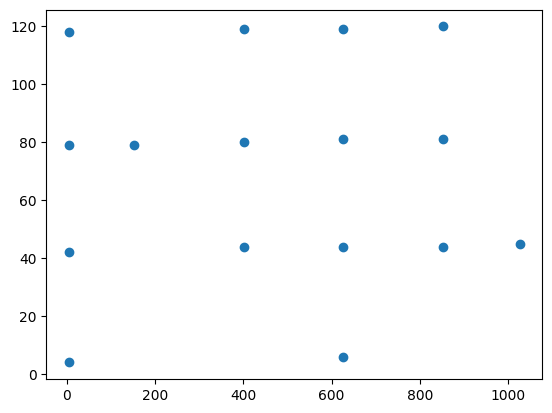

In [12]:
box_x = [box[0] for box in boxes]
box_y = [box[1] for box in boxes]

plt.scatter(box_x, box_y)

In [13]:
#Table

type_start_point = (50, 1000)
type_end_point = (1600, 1400)

x1 = min(type_start_point[0], type_end_point[0])
x2 = max(type_start_point[0], type_end_point[0])
y1 = min(type_start_point[1], type_end_point[1])
y2 = max(type_start_point[1], type_end_point[1])

text = None
cv2_image = cv2.cvtColor(np.array(cv2_image), cv2.COLOR_RGB2BGR)
roi = cv2_image[y1:y2, x1:x2] #initial box for address
text = pytesseract.image_to_string(roi, config='--psm 12')

#try to read by column - maybe split up by smaller rectangles?

#read first row, read second and see if there's a name: if not, append
cells = []
stripped_text = text.strip().splitlines()
prohibited = ["Detainees Involved", "Name", "Date of Birth", "Date Confined", "Arresting Charge", "|"]
for element in stripped_text:
    if element and element not in prohibited:
        cells.append(element)

multiples = [4,8,12,16]
for row in multiples:
    if len(cells) > row:
        if "|" in cells[row]:
            for extra_charge in cells[row:]:
                cells[row-1] += extra_charge
            cells = cells[:row]
        
print (cells)

['Pringle, Adam', '04/18/1990', '12/20/2020', 'Agg Batt/Peace Officer']


In [14]:
#Injuries

type_start_point = (300, 1380)
type_end_point = (1600, 1450)

x1 = min(type_start_point[0], type_end_point[0])
x2 = max(type_start_point[0], type_end_point[0])
y1 = min(type_start_point[1], type_end_point[1])
y2 = max(type_start_point[1], type_end_point[1])

print (roi_width)

roi_width = x2 - x1

text = None
cv2_image = cv2.cvtColor(np.array(cv2_image), cv2.COLOR_RGB2BGR)
roi = cv2_image[y1:y2, x1:x2] #initial box for dates
blurred_image = cv2.GaussianBlur(roi, (5, 5), 0)
edges = cv2.Canny(blurred_image, 50, 150) #get contoured polygons
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
for contour in contours:
    approx = cv2.approxPolyDP(contour, 0.04 * cv2.arcLength(contour, True), True) #get polgyon curve
    if len(approx) == 4 and cv2.isContourConvex(approx):
        x, y, w, h = cv2.boundingRect(approx)
        aspect_ratio = float(w) / h
        area = cv2.contourArea(approx) 
        if 0.85 <= aspect_ratio <= 1.15 and 250 <= area <= 5000: #check if its a box
            cropped_rect = roi[y : (y + h), x : (x + w)]
            gray_box = cv2.cvtColor(cropped_rect, cv2.COLOR_BGR2GRAY)
            _, binary = cv2.threshold(gray_box, 150, 255, cv2.THRESH_BINARY_INV)
            # Crop inside to ignore border (e.g. 10% margin)
            margin = int(min(w, h) * 0.1)
            inner = binary[margin:h-margin, margin:w-margin]
            fill_ratio = cv2.countNonZero(inner) / float(inner.size) #check how much is filled
            is_filled = fill_ratio > 0.2  # can adjust threashold
            print(f"Checkbox at ({x},{y}) - Filled: {is_filled}, Fill Ratio: {fill_ratio:.2f}")
            if is_filled:
                if x < roi_width*0.02:
                    text = "No injuries reported"
                else:
                    text_offset_x = 5  # pixels to skip after box
                    text_width = 1200    # width of text region to extract
                    text_roi = roi[y:y+h, x+w+text_offset_x:x+w+text_offset_x+text_width]
                    text_gray = cv2.cvtColor(text_roi, cv2.COLOR_BGR2GRAY)
                    _, text_thresh = cv2.threshold(text_gray, 150, 255, cv2.THRESH_BINARY)
                    text = pytesseract.image_to_string(text_thresh, config='--psm 6') #gets first letters of the phrase

print (text)

1310
Checkbox at (93,41) - Filled: True, Fill Ratio: 0.45
Yes. (briefly describe): Inmate potentially hit his head during seizure BS



In [15]:
#Resulting Death

type_start_point = (350, 1450)
type_end_point = (1600, 1530)

x1 = min(type_start_point[0], type_end_point[0])
x2 = max(type_start_point[0], type_end_point[0])
y1 = min(type_start_point[1], type_end_point[1])
y2 = max(type_start_point[1], type_end_point[1])

cv2_image = cv2.cvtColor(np.array(cv2_image), cv2.COLOR_RGB2BGR)
roi = cv2_image[y1:y2, x1:x2] #initial box for dates
blurred_image = cv2.GaussianBlur(roi, (5, 5), 0)
edges = cv2.Canny(blurred_image, 50, 150) #get contoured polygons
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
for contour in contours:
    approx = cv2.approxPolyDP(contour, 0.04 * cv2.arcLength(contour, True), True) #get polgyon curve
    if len(approx) == 4 and cv2.isContourConvex(approx):
        x, y, w, h = cv2.boundingRect(approx)
        aspect_ratio = float(w) / h
        area = cv2.contourArea(approx) 
        if 0.85 <= aspect_ratio <= 1.15 and 250 <= area <= 5000: #check if its a box
            cropped_rect = roi[y : (y + h), x : (x + w)]
            gray_box = cv2.cvtColor(cropped_rect, cv2.COLOR_BGR2GRAY)
            _, binary = cv2.threshold(gray_box, 150, 255, cv2.THRESH_BINARY_INV)
            # Crop inside to ignore border (e.g. 10% margin)
            margin = int(min(w, h) * 0.1)
            inner = binary[margin:h-margin, margin:w-margin]
            fill_ratio = cv2.countNonZero(inner) / float(inner.size) #check how much is filled
            is_filled = fill_ratio > 0.25  # can adjust threashold
            print(f"Checkbox at ({x},{y}) - Filled: {is_filled}, Fill Ratio: {fill_ratio:.2f}")

            if is_filled:
                text_offset_x = 5  # pixels to skip after box
                text_width = 50    # width of text region to extract
                text_roi = roi[y:y+h, x+w+text_offset_x:x+w+text_offset_x+text_width]
                text_gray = cv2.cvtColor(text_roi, cv2.COLOR_BGR2GRAY)
                _, text_thresh = cv2.threshold(text_gray, 150, 255, cv2.THRESH_BINARY)
                text = pytesseract.image_to_string(text_thresh, config='--psm 6') #gets first letters of the phrase

print (text)

Checkbox at (143,26) - Filled: False, Fill Ratio: 0.22
Checkbox at (43,26) - Filled: True, Fill Ratio: 0.43
No



In [16]:
#Deceased, Cause, Date and Time

type_start_point = (100, 1510)
type_end_point = (1600, 1700)

x1 = min(type_start_point[0], type_end_point[0])
x2 = max(type_start_point[0], type_end_point[0])
y1 = min(type_start_point[1], type_end_point[1])
y2 = max(type_start_point[1], type_end_point[1])

text = None
cv2_image = cv2.cvtColor(np.array(cv2_image), cv2.COLOR_RGB2BGR)
roi = cv2_image[y1:y2, x1:x2] #initial box for address
text = pytesseract.image_to_string(roi, config='--psm 6')

print (text)

Name of deceased: N/A
Specific cause of death: N/A
Date & time of death: N/A



In [17]:
#Suicide Watch

type_start_point = (1000, 1700)
type_end_point = (1300, 1780)

x1 = min(type_start_point[0], type_end_point[0])
x2 = max(type_start_point[0], type_end_point[0])
y1 = min(type_start_point[1], type_end_point[1])
y2 = max(type_start_point[1], type_end_point[1])

text = "NA"
cv2_image = cv2.cvtColor(np.array(cv2_image), cv2.COLOR_RGB2BGR)
roi = cv2_image[y1:y2, x1:x2] #initial box for dates
blurred_image = cv2.GaussianBlur(roi, (5, 5), 0)
edges = cv2.Canny(blurred_image, 50, 150) #get contoured polygons
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
for contour in contours:
    approx = cv2.approxPolyDP(contour, 0.04 * cv2.arcLength(contour, True), True) #get polgyon curve
    if len(approx) == 4 and cv2.isContourConvex(approx):
        x, y, w, h = cv2.boundingRect(approx)
        aspect_ratio = float(w) / h
        area = cv2.contourArea(approx) 
        if 0.85 <= aspect_ratio <= 1.15 and 250 <= area <= 5000: #check if its a box
            cropped_rect = roi[y : (y + h), x : (x + w)]
            gray_box = cv2.cvtColor(cropped_rect, cv2.COLOR_BGR2GRAY)
            _, binary = cv2.threshold(gray_box, 150, 255, cv2.THRESH_BINARY_INV)
            # Crop inside to ignore border (e.g. 10% margin)
            margin = int(min(w, h) * 0.1)
            inner = binary[margin:h-margin, margin:w-margin]
            fill_ratio = cv2.countNonZero(inner) / float(inner.size) #check how much is filled
            is_filled = fill_ratio > 0.5  # can adjust threashold
            print(f"Checkbox at ({x},{y}) - Filled: {is_filled}, Fill Ratio: {fill_ratio:.2f}")

            if is_filled:
                text_offset_x = 5  # pixels to skip after box
                text_width = 40    # width of text region to extract
                text_roi = roi[y:y+h, x+w+text_offset_x:x+w+text_offset_x+text_width]
                text_gray = cv2.cvtColor(text_roi, cv2.COLOR_BGR2GRAY)
                _, text_thresh = cv2.threshold(text_gray, 150, 255, cv2.THRESH_BINARY)
                text = pytesseract.image_to_string(text_thresh, config='--psm 6') #gets first letters of the phrase

print (text)

Checkbox at (166,16) - Filled: False, Fill Ratio: 0.23
Checkbox at (16,16) - Filled: False, Fill Ratio: 0.20
NA


In [18]:
#Reported By

type_start_point = (100, 1750)
type_end_point = (1600, 1820)

x1 = min(type_start_point[0], type_end_point[0])
x2 = max(type_start_point[0], type_end_point[0])
y1 = min(type_start_point[1], type_end_point[1])
y2 = max(type_start_point[1], type_end_point[1])

text = None
cv2_image = cv2.cvtColor(np.array(cv2_image), cv2.COLOR_RGB2BGR)
roi = cv2_image[y1:y2, x1:x2] #initial box for address
text = pytesseract.image_to_string(roi, config='--psm 6')

print (text)

Reported by: N/A 4



In [19]:
#Was deceased examined

type_start_point = (640, 1820)
type_end_point = (1600, 1880)

x1 = min(type_start_point[0], type_end_point[0])
x2 = max(type_start_point[0], type_end_point[0])
y1 = min(type_start_point[1], type_end_point[1])
y2 = max(type_start_point[1], type_end_point[1])

roi_width = x2 - x1
print (roi_width)

text = None
cv2_image = cv2.cvtColor(np.array(cv2_image), cv2.COLOR_RGB2BGR)
roi = cv2_image[y1:y2, x1:x2] #initial box for dates
blurred_image = cv2.GaussianBlur(roi, (5, 5), 0)
edges = cv2.Canny(blurred_image, 50, 150) #get contoured polygons
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
for contour in contours:
    approx = cv2.approxPolyDP(contour, 0.04 * cv2.arcLength(contour, True), True) #get polgyon curve
    if len(approx) == 4 and cv2.isContourConvex(approx):
        x, y, w, h = cv2.boundingRect(approx)
        aspect_ratio = float(w) / h
        area = cv2.contourArea(approx) 
        if 0.85 <= aspect_ratio <= 1.15 and 250 <= area <= 5000: #check if its a box
            cropped_rect = roi[y : (y + h), x : (x + w)]
            gray_box = cv2.cvtColor(cropped_rect, cv2.COLOR_BGR2GRAY)
            _, binary = cv2.threshold(gray_box, 150, 255, cv2.THRESH_BINARY_INV)
            # Crop inside to ignore border (e.g. 10% margin)
            margin = int(min(w, h) * 0.1)
            inner = binary[margin:h-margin, margin:w-margin]
            fill_ratio = cv2.countNonZero(inner) / float(inner.size) #check how much is filled
            is_filled = fill_ratio > 0.2  # can adjust threashold
            print(f"Checkbox at ({x},{y}) - Filled: {is_filled}, Fill Ratio: {fill_ratio:.2f}")
            if is_filled:
                if x < roi_width*0.02:
                    text = "N/A"
                else:
                    text_offset_x = 5  # pixels to skip after box
                    text_width = 1200    # width of text region to extract
                    text_roi = roi[y:y+h, x+w+text_offset_x:x+w+text_offset_x+text_width]
                    text_gray = cv2.cvtColor(text_roi, cv2.COLOR_BGR2GRAY)
                    _, text_thresh = cv2.threshold(text_gray, 150, 255, cv2.THRESH_BINARY)
                    text = pytesseract.image_to_string(text_thresh, config='--psm 6') #gets first letters of the phrase

print (text)


960
Checkbox at (101,16) - Filled: True, Fill Ratio: 0.25
Checkbox at (0,16) - Filled: True, Fill Ratio: 0.24
N/A


In [20]:
#Did diceased display signs of illness 

type_start_point = (640, 1880)
type_end_point = (1600, 1940)

x1 = min(type_start_point[0], type_end_point[0])
x2 = max(type_start_point[0], type_end_point[0])
y1 = min(type_start_point[1], type_end_point[1])
y2 = max(type_start_point[1], type_end_point[1])

roi_width = x2 - x1

print (roi_width)

text = None
cv2_image = cv2.cvtColor(np.array(cv2_image), cv2.COLOR_RGB2BGR)
roi = cv2_image[y1:y2, x1:x2] #initial box for dates
blurred_image = cv2.GaussianBlur(roi, (5, 5), 0)
edges = cv2.Canny(blurred_image, 50, 150) #get contoured polygons
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
for contour in contours:
    approx = cv2.approxPolyDP(contour, 0.04 * cv2.arcLength(contour, True), True) #get polgyon curve
    if len(approx) == 4 and cv2.isContourConvex(approx):
        x, y, w, h = cv2.boundingRect(approx)
        aspect_ratio = float(w) / h
        area = cv2.contourArea(approx) 
        if 0.85 <= aspect_ratio <= 1.15 and 250 <= area <= 5000: #check if its a box
            cropped_rect = roi[y : (y + h), x : (x + w)]
            gray_box = cv2.cvtColor(cropped_rect, cv2.COLOR_BGR2GRAY)
            _, binary = cv2.threshold(gray_box, 150, 255, cv2.THRESH_BINARY_INV)
            # Crop inside to ignore border (e.g. 10% margin)
            margin = int(min(w, h) * 0.1)
            inner = binary[margin:h-margin, margin:w-margin]
            fill_ratio = cv2.countNonZero(inner) / float(inner.size) #check how much is filled
            is_filled = fill_ratio > 0.2  # can adjust threashold
            print(f"Checkbox at ({x},{y}) - Filled: {is_filled}, Fill Ratio: {fill_ratio:.2f}")
            if is_filled:
                if x < roi_width*0.02:
                    text = "N/A"
                else:
                    text_offset_x = 5  # pixels to skip after box
                    text_width = 800    # width of text region to extract
                    text_roi = roi[y:y+h, x+w+text_offset_x:x+w+text_offset_x+text_width]
                    text_gray = cv2.cvtColor(text_roi, cv2.COLOR_BGR2GRAY)
                    _, text_thresh = cv2.threshold(text_gray, 150, 255, cv2.THRESH_BINARY)
                    first_line_text = pytesseract.image_to_string(text_thresh, config='--psm 6') #gets first letters of the phrase

                    type_start_point = (100,1940)
                    type_end_point = (1600,2000)

                    x1 = min(type_start_point[0], type_end_point[0])
                    x2 = max(type_start_point[0], type_end_point[0])
                    y1 = min(type_start_point[1], type_end_point[1])
                    y2 = max(type_start_point[1], type_end_point[1])

                    text = None
                    cv2_image = cv2.cvtColor(np.array(cv2_image), cv2.COLOR_RGB2BGR)
                    roi = cv2_image[y1:y2, x1:x2] #initial box for address
                    second_line_text = pytesseract.image_to_string(roi, config='--psm 6')

                    text = first_line_text + second_line_text

print (text)



960
Checkbox at (0,17) - Filled: True, Fill Ratio: 0.25
Checkbox at (101,17) - Filled: True, Fill Ratio: 0.24
Yes. describe: N/A.



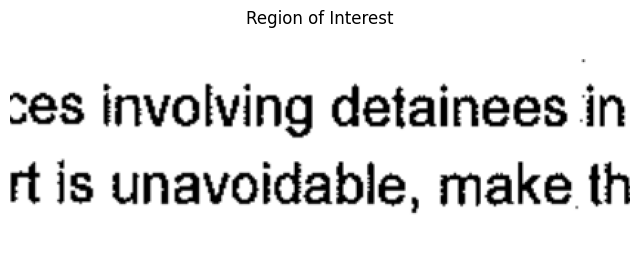

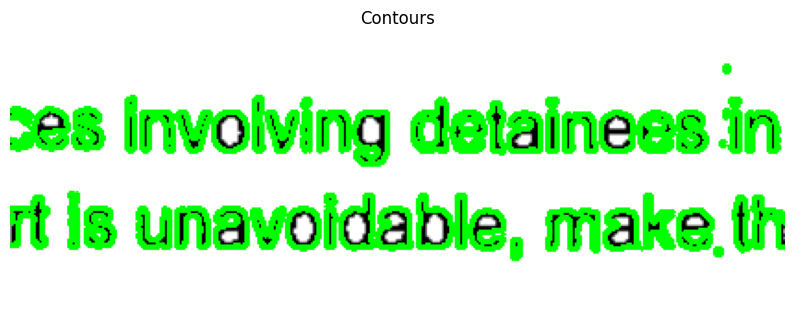

In [28]:
# Convert BGR to RGB for correct display with matplotlib
roi_rgb = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)
image_with_contours = roi.copy()
cv2.drawContours(image_with_contours, contours, -1, (0, 255, 0), 2)
image_with_contours_rgb = cv2.cvtColor(image_with_contours, cv2.COLOR_BGR2RGB)

# Display ROI
plt.figure(figsize=(8, 4))
plt.title("Region of Interest")
plt.imshow(roi_rgb)
plt.axis('off')
plt.show()

# Display contours
plt.figure(figsize=(10, 6))
plt.title("Contours")
plt.imshow(image_with_contours_rgb)
plt.axis('off')
plt.show()

Notes:
- Need to turn page to black and white, contrast
- Need to break into smaller sections
- Identify four corners of the document on an angled document, do a coordinate projection
- Define regions for model to do dvisions
- Turn image into array, do conversions with color, blur slightly (cv2)
- Read cv2 functions - Canny could find boxes to fill in
- For boxes ---> Look at average value of pixels inside
- Every page should a row in a tabular dataset

Sections to break up:
- County/Municipal/Chicago PD *
- Faciltiy Name
- Telephone #
- Address
- Date
- Time *
- Type of Occurence *
- Detainees Table
- Any Injuries *
- Any resulting death? *
- Other death/injury data?